In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers

In [ ]:
np.random.seed(24) #to produce similar data sets every time we use the random function 

#Function 1
x = np.random.uniform(0, 2*np.pi, (1000, 1)) #where 1000 is the number of samples we're using for x
y = np.sin(x) #defining what the output should be

#for 2nd function
x1 = np.random.uniform(0, 2*np.pi, (2000, 1))
x2 = np.random.uniform(0, 2*np.pi, (2000, 1))

x3 = np.hstack([x1, x2])   # shape (N,2)

# Function 2 is defined as:
y3 = np.sin(x1) + np.cos(x2)


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24) 
#dividing the total sample space into testing and training values, in which 0.2 of it is the size of the testing data

#training and testing values for second function
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=24)

print(x3.shape)        # should be (N, 2)
print(x3_train.shape)  # should be (N, 2)

(2000, 2)
(1600, 2)


In [17]:
def build_model(nodes=20, layers=2, lr=0.01, activation='tanh', l2_reg=0.0): #We use the activation function tanh for the function sinx as it is the closest approximation
    model = keras.Sequential()
    
    # Input + hidden layers
    for i in range(layers):
        if i == 0:
            model.add(keras.layers.Dense(nodes, activation=activation, input_shape=(1,), kernel_regularizer=regularizers.l2(l2_reg)))
        else:
            model.add(keras.layers.Dense(nodes, activation=activation, kernel_regularizer=regularizers.l2(l2_reg)))
    
    # Output layer
    model.add(keras.layers.Dense(1))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    
    return model

#building the model for second function
model2 = keras.Sequential([keras.layers.Dense(50, activation='tanh', input_shape=(2,)), keras.layers.Dense(50, activation='tanh'), keras.layers.Dense(1)])

model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

## Prediction + Parity Plot

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


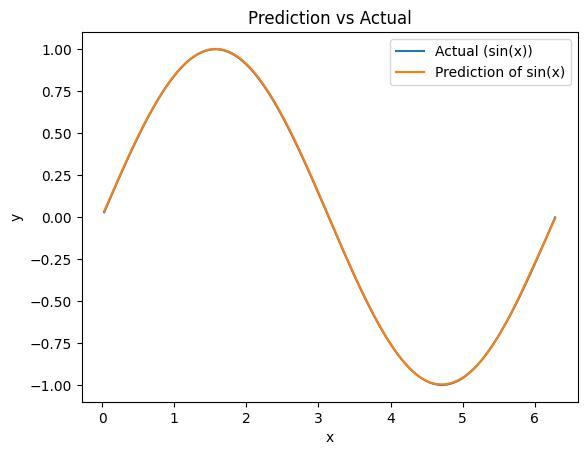

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


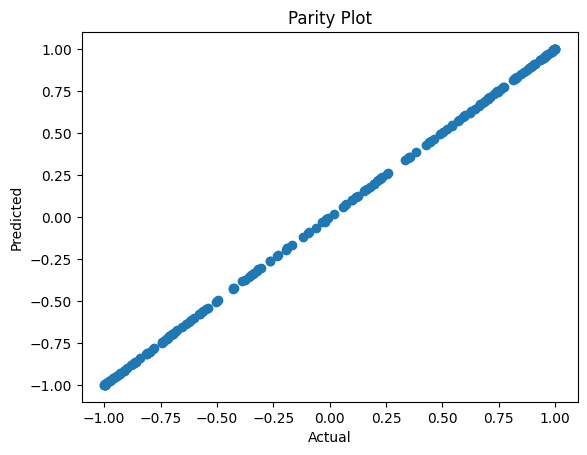

In [ ]:
model = build_model()
model.fit(x_train, y_train, epochs=300, verbose=0) #Function for already built model of neural network

y_pred = model.predict(x) #function for predicting all the values of y for the entire sample space x

sorted_idx = np.argsort(x[:, 0]) #argsort is giving the indices of x after sorting

x_sorted = x[sorted_idx] #sorting x
y_sorted = y[sorted_idx] #sorting y
y_pred_sorted = y_pred[sorted_idx] #sorting predicted values of y

#Plotting Prediction and actual values in the same plot
plt.figure()
plt.plot(x_sorted, y_sorted, label="Actual (sin(x))")
plt.plot(x_sorted, y_pred_sorted, label="Prediction of sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Prediction vs Actual")
plt.legend()
plt.show()

y_test_pred = model.predict(x_test) #function for predicting all the values of y for the testing values of x


#Plotting the Parity Plot
plt.figure()
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot")
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


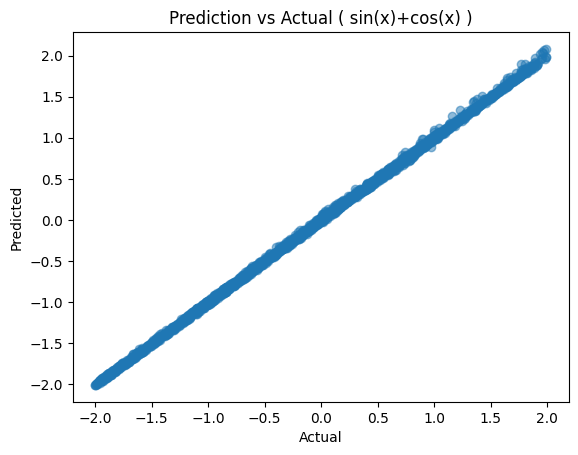

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


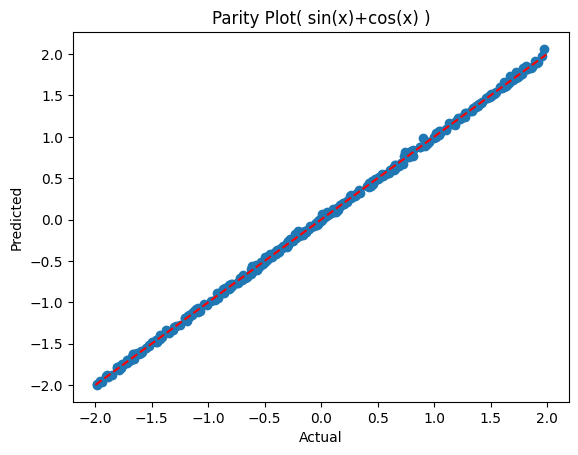

In [19]:
#for second function
model2.fit(x3_train, y3_train, epochs=300, verbose=0)
y3_pred = model2.predict(x3)

plt.figure()
plt.scatter(y3, y3_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual ( sin(x)+cos(x) )")
plt.show()

y3_test_pred = model2.predict(x3_test)

plt.figure()
plt.scatter(y3_test, y3_test_pred)
plt.plot([y3.min(), y3.max()], [y3.min(), y3.max()], 'r--')  # diagonal line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot( sin(x)+cos(x) )")
plt.show()




## Nodes vs Error

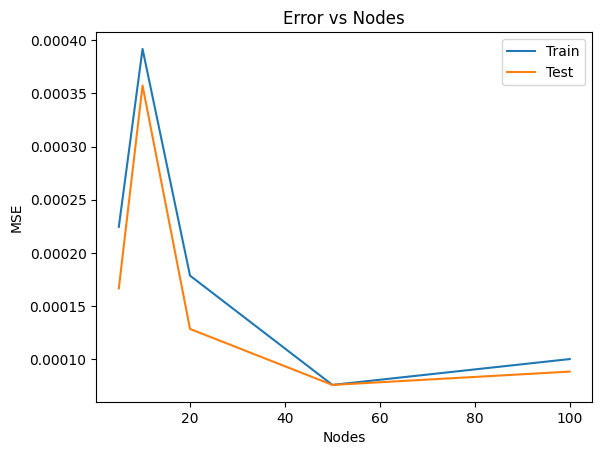

In [20]:
nodes_list = [5, 10, 20, 50, 100]

train_err = []
test_err = []

for nodes in nodes_list:
    model = build_model(nodes=nodes)
    model.fit(x_train, y_train, epochs=200, verbose=0)
    
    train_err.append(model.evaluate(x_train, y_train, verbose=0))
    test_err.append(model.evaluate(x_test, y_test, verbose=0))

plt.plot(nodes_list, train_err, label="Train")
plt.plot(nodes_list, test_err, label="Test")
plt.xlabel("Nodes")
plt.ylabel("MSE")
plt.legend()
plt.title("Error vs Nodes")
plt.show()

## Noise Study


--- Noise Level: 0.0 ---


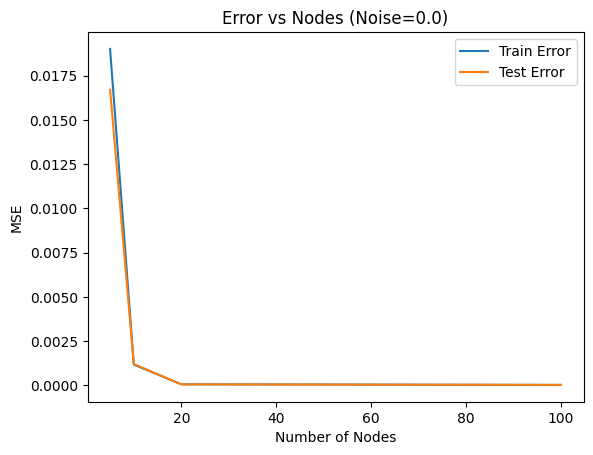


--- Noise Level: 0.1 ---


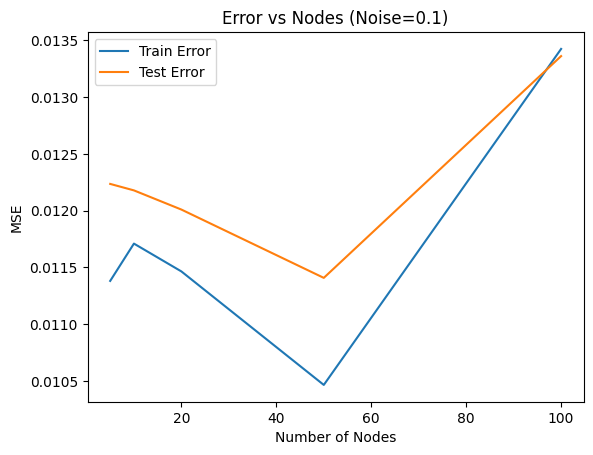


--- Noise Level: 0.3 ---


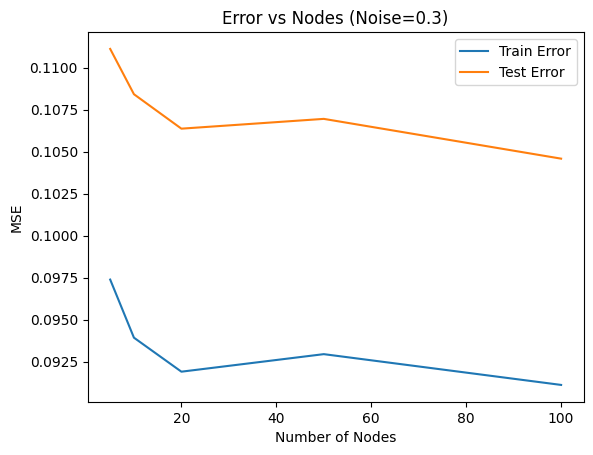

In [ ]:
noise_levels = [0.0, 0.1, 0.3]
nodes_list = [5, 10, 20, 50, 100]

for noise in noise_levels:
    print(f"\n--- Noise Level: {noise} ---")
    
    # Add noise
    y_noisy = np.sin(x) + noise * np.random.randn(*y.shape)
    
    # Split
    x_train, x_test, y_train, y_test = train_test_split(x, y_noisy, test_size=0.2, random_state=42)
    
    train_err = []
    test_err = []
    
    for nodes in nodes_list:
        model = keras.Sequential([keras.layers.Dense(nodes, activation='tanh', input_shape=(1,)), keras.layers.Dense(nodes, activation='tanh'), keras.layers.Dense(1)])
        
        model.compile(optimizer='adam', loss='mse')
        model.fit(x_train, y_train, epochs=200, verbose=0)
        
        train_err.append(model.evaluate(x_train, y_train, verbose=0))
        test_err.append(model.evaluate(x_test, y_test, verbose=0))
    
    # Plot
    plt.figure()
    plt.plot(nodes_list, train_err, label="Train Error")
    plt.plot(nodes_list, test_err, label="Test Error")
    plt.xlabel("Number of Nodes")
    plt.ylabel("MSE")
    plt.title(f"Error vs Nodes (Noise={noise})")
    plt.legend()
    plt.show()

## Data Size vs Error (Overfitting)

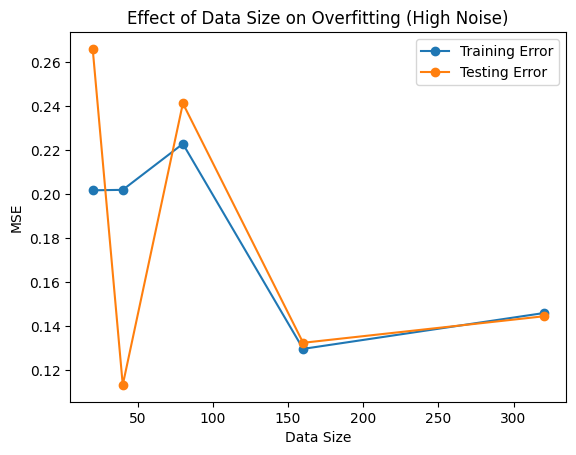

In [ ]:
noise = 0.3

np.random.seed(42)
x = np.random.uniform(0, 2*np.pi, (100, 1))
y = np.sin(x) + noise * np.random.randn(*x.shape)

sizes = [20, 40, 80, 160, 320]

train_err = []
test_err = []

for size in sizes:
    
    x_small = x[:size]
    y_small = y[:size]
    
    x_train, x_test, y_train, y_test = train_test_split(x_small, y_small, test_size=0.2, random_state=42)
    
    model = keras.Sequential([keras.layers.Dense(1000, activation='tanh', input_shape=(1,)), keras.layers.Dense(1000, activation='tanh'), keras.layers.Dense(1)])
    
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(x_train, y_train, epochs=300, verbose=0)
    
    train_err.append(model.evaluate(x_train, y_train, verbose=0))
    test_err.append(model.evaluate(x_test, y_test, verbose=0))

plt.figure()
plt.plot(sizes, train_err, 'o-', label="Training Error")
plt.plot(sizes, test_err, 'o-', label="Testing Error")
plt.xlabel("Data Size")
plt.ylabel("MSE")
plt.title("Effect of Data Size on Overfitting (High Noise)")
plt.legend()
plt.show()

## L2 Regularization

In [24]:
#For model in overfitting region
x_train = np.linspace(0, 2*np.pi, 15).reshape(-1, 1)  # only 15 points
y_train = np.sin(x_train)

# Model WITHOUT regularization
model_no_reg = keras.Sequential([keras.layers.Dense(256, activation='tanh', input_shape=(1,)), keras.layers.Dense(256, activation='tanh'), keras.layers.Dense(1)])

model_no_reg.compile(optimizer='adam', loss='mse')
model_no_reg.fit(x_train, y_train, epochs=600, verbose=0)

# Model WITH L2 regularization
model_reg = keras.Sequential([keras.layers.Dense(256, activation='tanh', kernel_regularizer=keras.regularizers.l2(0.00001), input_shape=(1,)), 
                              keras.layers.Dense(256, activation='tanh', kernel_regularizer=keras.regularizers.l2(0.00001)), 
                              keras.layers.Dense(1)])

#too high of a regularisation parameter leads to underfitting due to over-regularisation. So we use l = 0.00001

model_reg.compile(optimizer='adam', loss='mse')
model_reg.fit(x_train, y_train, epochs=600, verbose=0)

print("WITHOUT regularization:")
print("Train MSE:", model_no_reg.evaluate(x_train, y_train, verbose=0))
print("Test  MSE:", model_no_reg.evaluate(x_test, y_test, verbose=0))

print("\nWITH regularization:")
print("Train MSE:", model_reg.evaluate(x_train, y_train, verbose=0))
print("Test  MSE:", model_reg.evaluate(x_test, y_test, verbose=0))

c:\Users\kaash\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


WITHOUT regularization:
Train MSE: 0.0010160936508327723
Test  MSE: 0.06599107384681702

WITH regularization:
Train MSE: 0.009282729588449001
Test  MSE: 0.0777786448597908


## Learning Rate Study

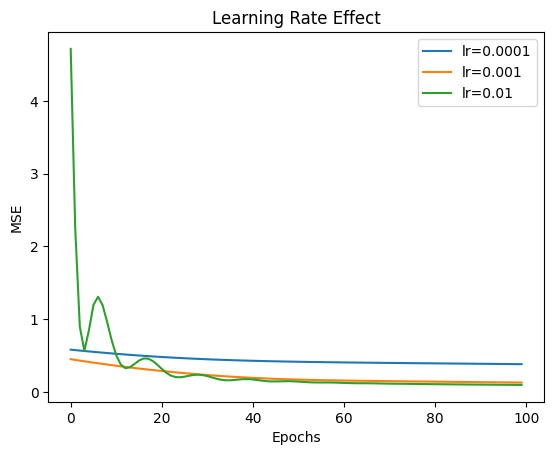

In [25]:
lr_list = [0.0001, 0.001, 0.01]

for lr in lr_list:
    model = build_model(lr=lr)
    history = model.fit(x_train, y_train, epochs=100, verbose=0)
    
    plt.plot(history.history['loss'], label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Effect")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

## Layers Study

In [26]:
layers_list = [1, 2, 3, 4]

#
for l in layers_list:
    model = build_model(layers=l)
    model.fit(x_train, y_train, epochs=200, verbose=0)
    
    test_loss = model.evaluate(x_test, y_test, verbose=0)
    print(f"Layers={l}, Test Loss={test_loss:.4f}")

Layers=1, Test Loss=0.1482
Layers=2, Test Loss=0.0624
Layers=3, Test Loss=0.0639
Layers=4, Test Loss=0.0615


## Activation Functions

In [27]:
activations = ['relu', 'tanh', 'sigmoid']

for act in activations:
    model = build_model(activation=act)
    model.fit(x_train, y_train, epochs=200, verbose=0)
    
    loss = model.evaluate(x_test, y_test, verbose=0)
    print(f"{act} → Test Loss = {loss:.4f}")

relu → Test Loss = 0.1167
tanh → Test Loss = 0.0616
sigmoid → Test Loss = 0.2215
